# 1. Scoring one recording

This notebook takes a recording and produces a hypnogram: WAKE / NREM / REM.

Each cell is a few lines, because the work lives in `nyx.pipeline`. What is left
in the notebook is the parts where **you** have to decide something. There are
four:

1. the analysis window — where usable signal starts and ends,
2. the EMG wake/sleep threshold,
3. the clustering settings,
4. which cluster is REM and which is NREM.

Every one has an automatic default.

**It runs as-is, with no data.** Section 2 uses a synthetic recording, so you can
work through the whole thing before pointing it at your own file. Bear in mind
that synthetic signal is built to contain exactly the structure nyx looks for, so
it scores near-perfectly.

A manually scored reference is **optional**. Section 7 is skipped without one.

## 1. Setup

In [1]:
import os

# One thread per linear-algebra library: the pipeline is not parallel, and
# oversubscribing makes it considerably slower.
for _var in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS",
             "NUMEXPR_NUM_THREADS", "BLIS_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_var] = "1"

import matplotlib.pyplot as plt

import nyx

print("nyx", nyx.__version__)

nyx 0.1.0


## 2. Load a recording

The default is synthetic, so this notebook runs with nothing downloaded. To use
your own file, replace the cell below with:

```python
recording = nyx.read_recording(r"...\A31_D04.edf", eeg_channel=0, emg_channel=1)
reference = None
params = nyx.load_params("../params/mouse.json")
OUTPUT_DIR = "../results/A31_D04"
```

`eeg_channel` / `emg_channel` take either a position (`0` = first channel in the
file) or a channel name (`"EEG"`).

**Always read `describe()` before going on.** Picking the wrong channel is the
most common mistake.

In [2]:
recording, reference = nyx.demo_recording()
params = nyx.demo_params()
OUTPUT_DIR = "demo_output/01_score_recording"

print(recording.describe())

demo: 4000.0s at 128 Hz
  EEG channel: EEG
  EMG channel: EMG


c:\Users\letizias\.conda\envs\nyx_dev\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Datasets nyx already knows

For the public datasets used in the paper, a recipe knows the folder layout and
the scoring format, so you give a root and a recording name:

```python
from nyx.datasets import list_datasets, load_dataset

list_datasets()
recording, reference = load_dataset(
    "gulledge-2025",
    data_root=r"...\data",
    sub_dataset="Saline (N=4)",
    recording_name="A31_D04",
)
```

## 3. Decision 1 — the analysis window

Look at the signal before scoring it. `check_signals` shows the start and the end
of the recording as traces plus spectrograms, and measures mains interference.

`02_signal_check.ipynb` goes into this properly, including what a bad recording
looks like and what fixing it is worth.

demo: 4000s at 128 Hz
  previewed: full 0-4000s
  line-noise check (peak above local baseline):
    EEG_50Hz         +0.2 dB
    EEG_60Hz         +0.3 dB
    EMG_50Hz         +0.4 dB
    EMG_60Hz         +0.3 dB
  suggestion: no notch needed.


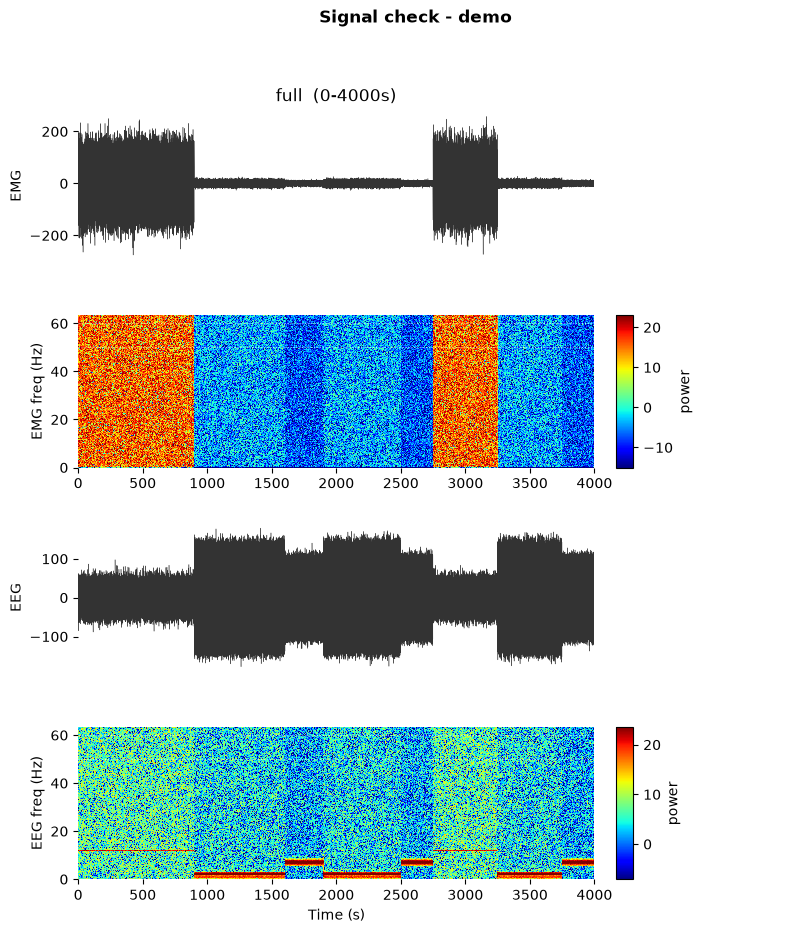

In [4]:
check = nyx.check_signals(recording)
print(check.summary())
check.plot()
plt.show()

In [5]:
# None = the whole recording. Otherwise (start, end) in seconds.
WINDOW = None

# A notch belongs in the params so that it is recorded and replayed:
#     params["EEG"]["notch"] = check.suggested_notch()
print(f"suggested notch: {check.suggested_notch()}")

suggested notch: None


## 4. Decision 2 — the EMG wake/sleep threshold

EMG power is high in wake and low in sleep, so a threshold between the two modes
separates them. The automatic cut fits a Gaussian mixture; check that it sits in
the valley, and override it if not.

automatic EMG threshold: 0.933


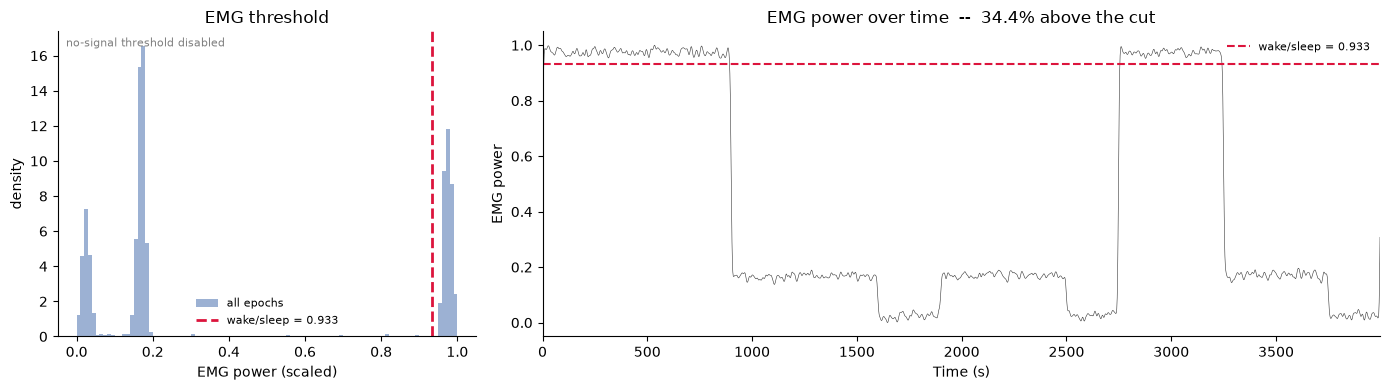

In [ ]:
windowed = recording if WINDOW is None else recording.time_slice(*WINDOW)
window = (0.0, recording.duration) if WINDOW is None else WINDOW

emg = nyx.compute_emg_features(windowed, params)

# Epochs at or below NOSIGNAL are treated as signal loss rather than as sleep.
# 0.0 disables it.
NOSIGNAL = 0.0

auto_threshold = nyx.find_wake_sleep_threshold(emg, nosignal_threshold=NOSIGNAL)
print(f"automatic EMG threshold: {auto_threshold:.3f}")
nyx.plot_emg_check(emg, threshold=auto_threshold, nosignal=NOSIGNAL)
plt.show()

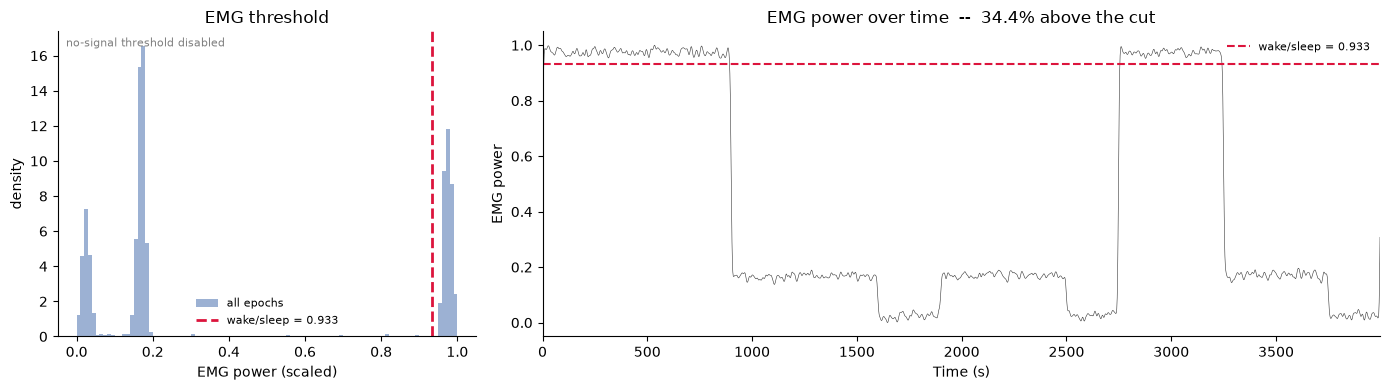

In [7]:
# None = keep the automatic threshold. A number overrides it.
EMG_THRESHOLD = None
nyx.plot_emg_check(emg, threshold=auto_threshold, nosignal=NOSIGNAL)
plt.show()

using 0.933 (auto)


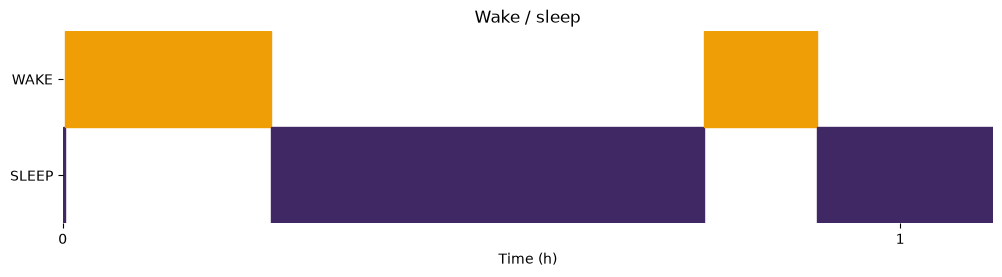

In [8]:
wake_sleep = nyx.classify_wake_sleep(
    emg,
    threshold=EMG_THRESHOLD,
    nosignal_threshold=NOSIGNAL,
    min_duration=params.get("scoring", {}).get("min_duration", 4.0),
)
print(f"using {wake_sleep.threshold:.3f} ({wake_sleep.threshold_source})")

nyx.plot_wake_sleep(wake_sleep)
plt.show()

### If the EMG does not separate cleanly

Some recordings have no usable valley — a weak EMG, or a recording too short for
the distribution to be bimodal. Rather than forcing a bad cut, set the threshold
*above* everything so every epoch starts as SLEEP, and let a clustering step
recover wake from the EEG instead:

```python
EMG_THRESHOLD = 1.1     # above the top of the min-max scaled power
```

Then cluster into three stages at once with `use_emg=True`, as
`params/mouse_weak_emg.json` does. With no EMG channel at all, see
`params/mouse_no_emg.json` and `nyx.emg_from_lfp`.

## 5. EEG spectral PCA

PCA is fitted **on the sleep epochs only**.

2624 sleep epochs, 4 components


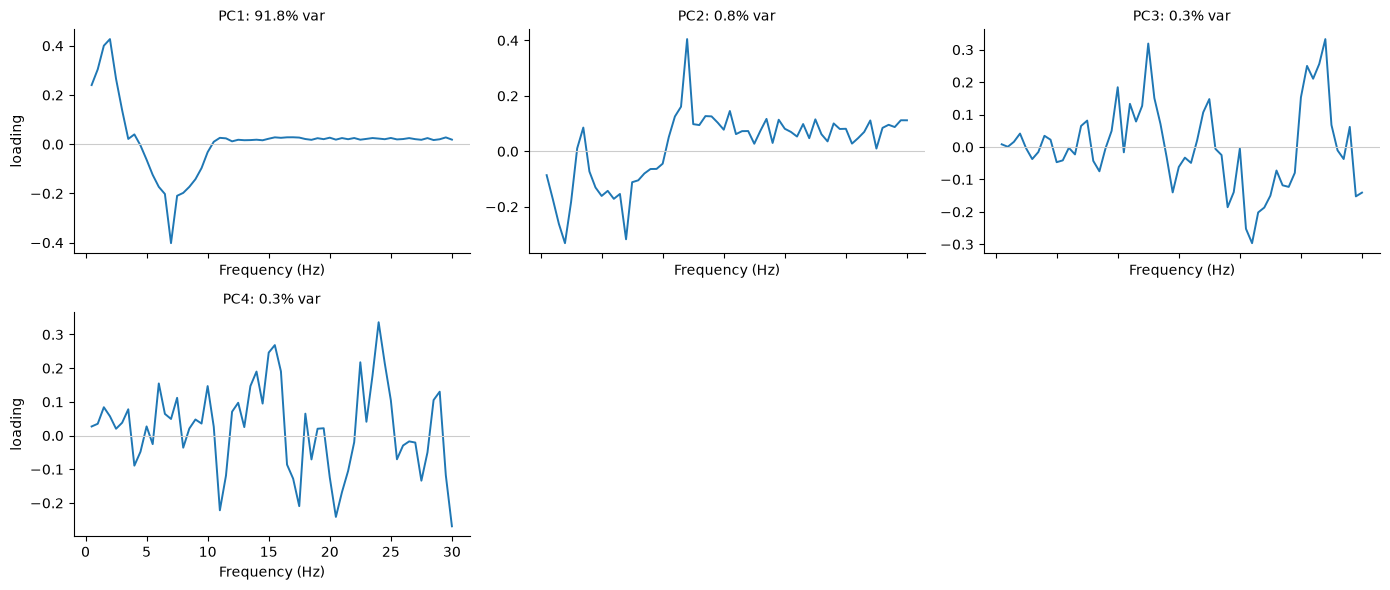

In [9]:
pca = nyx.compute_sleep_pca(windowed, params, wake_sleep)
print(f"{pca.scores.shape[0]} sleep epochs, {pca.scores.shape[1]} components")

nyx.plot_pca_grid(pca)
plt.show()

## 6. Decision 3 — clustering settings

Defaults come from `nyx.pipeline.DEFAULT_CLUSTERING` and are overridden by a
`clustering` section in the params file. Override them here while you are
experimenting, then write what worked back into the params.

`hdbscan` picks its own number of clusters from a density scale, which suits
NREM/REM. `kmeans` and `gmm` take a fixed `n_clusters`.

In [10]:
clustering = {
    "method": "hdbscan",          # hdbscan | kmeans | gmm | elliptic
    "n_clusters": 2,              # kmeans / gmm / elliptic only
    "pcs_to_use": [0, 1, 2, 3],
    "use_emg": False,             # add EMG power as an extra clustering feature
    "outlier_z_threshold": 6,     # beyond this |z| an epoch is marked NOSIGNAL
    "hdbscan_min_cluster_size": 300,
    "hdbscan_min_samples": 30,
}

clusters = nyx.cluster_sleep(pca, wake_sleep, clustering=clustering, emg=emg)
print("cluster sizes:", clusters.sizes())

cluster sizes: {0: 800, 1: 1800}


### The panel to check every time

The per-cluster spectra are what tell you the stage assignment is right:
**NREM should carry more low-frequency (delta) power than REM.** If it does not,
the assignment is wrong however clean the clusters look in PC space.

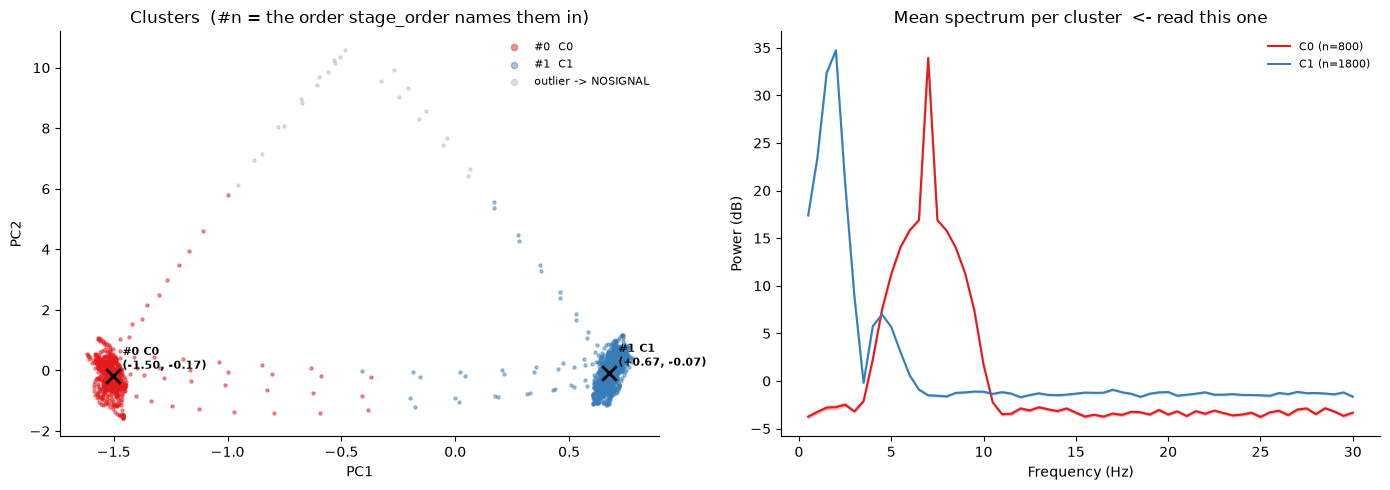

,cluster,PC1,PC2,PC3,PC4,epochs
order,,,,,,
0,0,-1.5039,-0.1711,0.0532,-0.0017,800
1,1,0.6736,-0.0696,0.0122,0.0082,1800


In [11]:
nyx.plot_cluster_check(pca, clusters=clusters)
plt.show()

# The exact centroids, in the order stage_order names them. 
nyx.cluster_ordering(clusters)

In [ ]:
# The clustering used more than the two dimensions drawn above -- further
# components, and the EMG when use_emg is set. This is the same scatter
# coloured by each of those in turn: if two clusters overlap in PC1/PC2,
# the panel whose colour changes across the boundary is what split them.
nyx.plot_cluster_features(clusters)
plt.show()

## Decision 4 — which cluster is REM

Clusters are ordered by their centroid on the first PC used, and `STAGE_ORDER`
names them by **position in that order** — the `order` column of the table
above, not the cluster id. REM usually sits lower, having less delta power —
but the sign of a principal component is arbitrary, so **check it against the
spectra above** rather than trusting the order.

If it is the wrong way round, flip `STAGE_ORDER` or set `OVERRIDES` by cluster
id. Cluster ids are renumbered by centroid, so an id means the same thing on
every run and a saved mapping stays valid.

In [12]:
STAGE_ORDER = ["REM", "NREM"]     # low PC1 -> high PC1
OVERRIDES = None                  # e.g. {0: "NREM", 1: "REM"}

staging = nyx.assign_stages(clusters, pca, wake_sleep,
                            stage_order=STAGE_ORDER, overrides=OVERRIDES)

for cid, stage in sorted(staging.cluster_to_stage.items()):
    print(f"  cluster {cid}  PC1 centroid {clusters.centers[cid, 0]:+.3f}  ->  {stage}")

durations = staging.stage_durations()
total = sum(durations.values())
print()
for stage, seconds in sorted(durations.items()):
    print(f"  {stage:<10} {seconds:9.1f}s ({100 * seconds / total:.1f}%)")

  cluster 0  PC1 centroid -1.504  ->  REM
  cluster 1  PC1 centroid +0.674  ->  NREM

  NOSIGNAL        24.0s (0.6%)
  NREM          1800.0s (45.0%)
  REM            800.0s (20.0%)
  WAKE          1375.0s (34.4%)


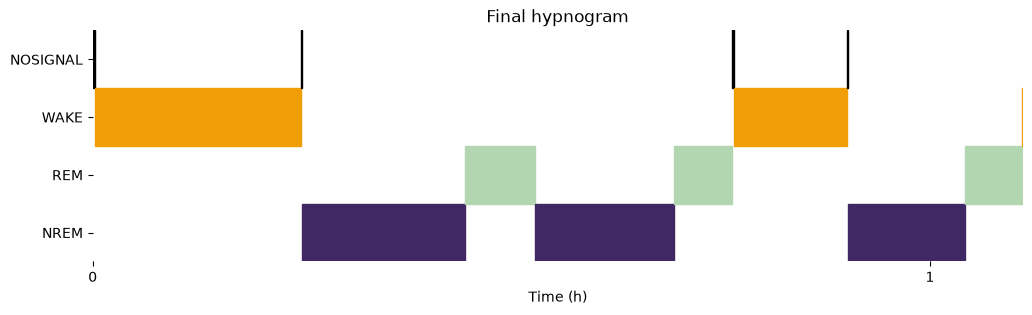

In [13]:
nyx.plot_hypnogram_result(staging, title="Final hypnogram")
plt.show()

### Cleaning up the sequence (optional)

Clustering scores each epoch on its own, so it has no notion of what a plausible
*sequence* looks like. An optional `postprocess` list in the params rewrites
implausible ones — REM straight out of wake, bouts too short to be real:

```python
params["postprocess"] = [
    {"rem_after_wake": {"min_wake_duration": 0}},
    {"min_duration":   {"seconds": 4}},
]
```

**Off by default, and worth leaving off unless you know which readout you are
protecting.** These rules barely move agreement but they do move the biology —
see `params/README.md` for what each one costs.

### Refining a cluster by hand (optional)

Draw a polygon around the epochs to relabel:

```python
%matplotlib qt
from nyx.interactive import PolygonSelector

fig, ax = plt.subplots(figsize=(12, 9))
ax.scatter(clusters.features_scaled[:, 0], clusters.features_scaled[:, 1], s=5)
selector = PolygonSelector(ax, clusters.features_scaled[:, :2])
plt.show()
```

## 7. Compare with a manual scoring — OPTIONAL

Only if you have one. nyx does not need it, and never used it to produce
anything above.

`read_annotations` handles the common layouts; tell it how yours is organised:

| your file | call |
|---|---|
| `time,duration,label` columns | `read_annotations(path)` |
| one row per epoch, stage as a number | `read_annotations(path, format="epoch_csv", epoch_length=10, label_map={1: "WAKE", 2: "NREM", 3: "REM"})` |
| one column per animal | `read_annotations(path, format="column_csv", column="A31", epoch_length=4, label_map={...})` |
| visbrain / somnotate `.hyp` | `read_annotations(path)` |
| NSRR XML | `read_annotations(path, format="nsrr_xml")` |

In [23]:
agreement = None
if reference is not None:
    agreement = nyx.evaluate(staging, reference, window=window)
else:
    print("No reference scoring - skipping. This is fine.")

=== Summary metrics (aggregated, fine-grained comparison) ===
MF1: 0.996    Accuracy: 0.993    Cohen's kappa: 0.989

     precision recall f1-score support
WAKE     0.999  0.981    0.990 1400.0s
REM      0.998  0.999    0.998  799.0s
NREM     0.999  0.999    0.999 1800.0s

Macro average (unweighted, over stages present in the reference):
          precision recall f1-score   support
macro avg     0.999  0.993    0.996  3999.000

Confusion matrix (rows=true, cols=predicted, values are in seconds):
        WAKE    REM    NREM
WAKE  1374.0    0.0     2.0
REM      1.0  798.0     0.0
NREM     0.0    2.0  1798.0


**MF1** is the headline number: the unweighted mean of the per-stage F1 scores.
Unweighted on purpose — REM is a small fraction of any recording, so weighting by
duration lets good wake/NREM performance hide a method that misses REM entirely.

## 8. Save

In [24]:
from nyx.pipeline import ScoringResult

result = ScoringResult(
    recording=windowed, emg=emg, wake_sleep=wake_sleep, pca=pca,
    clusters=clusters, staging=staging, agreement=agreement,
    window=window, total_duration=recording.duration, params=params,
    reference=reference,
)

nyx.save_results(result, OUTPUT_DIR)
print("saved to", os.path.abspath(OUTPUT_DIR))

Hypnogram saved to demo_output/01_score_recording\wake_sleep.csv with NOSIGNAL padding.
Hypnogram saved to demo_output/01_score_recording\hypnogram.csv with NOSIGNAL padding.
saved to f:\NCMM_sleep\signorelli2026\00_code\nyx\examples\demo_output\01_score_recording


That writes the hypnogram, every figure, and a `run.json` holding the parameters
plus every decision made above — window, thresholds, cluster mapping. Loading it
back re-runs this scoring exactly, with nothing left to choose:

```python
config = nyx.load_config("run.json")
```

---
## The whole notebook in one call

Once the defaults are good enough — for a batch, or after checking one recording
of a set — all of the above collapses to:

```python
result = nyx.score_recording(recording, params, window=WINDOW, reference=reference)
nyx.save_results(result, OUTPUT_DIR)
```

`score_recording` also runs the `steps` list in the params, so multi-step scoring
(human five stages, rodent substages) goes through the same call. See
`04_human_five_stage.ipynb`.

For many recordings, see `nyx.open_queue` -- it walks a CSV manifest one
recording at a time and remembers where you got to.